In [55]:
import pandas as pd
import numpy as np

df = pd.read_csv("ethiopia.csv")

df["Country"] = "Ethiopia"

In [41]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

In [42]:
df = df.replace(-999, np.nan)

In [43]:
df.duplicated().sum()
df = df.drop_duplicates()

In [44]:
df.describe()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

Interpretation:
After replacing NASA's sentinel value (-999) with NaN, the missing value report shows 0% missing values across all key columns. This indicates a high-quality, complete dataset for this region. The summary statistics show realistic ranges for temperature and humidity, with no obvious data entry errors remaining.

In [45]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

Interpretation:
The Z-score analysis flagged several potential outliers: 95 for Precipitation (PRECTOTCORR) and 18 for Minimum Temperature (T2M_MIN). Given that these represent extreme weather events (heavy rain or cold snaps) which are naturally occurring in climate data, I have chosen to retain them to ensure the model captures climate variability, rather than capping or dropping them.

In [46]:
df = df.ffill()
df = df.dropna(thresh=len(df.columns)*0.7)

In [47]:
import os

os.makedirs("data", exist_ok=True)
df.to_csv("data/ethiopia_clean.csv", index=False)

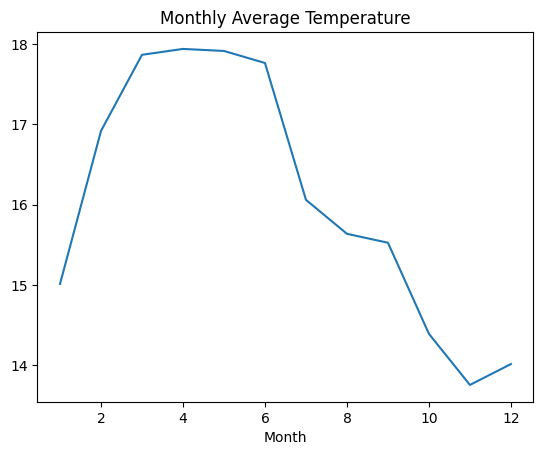

In [48]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.show()

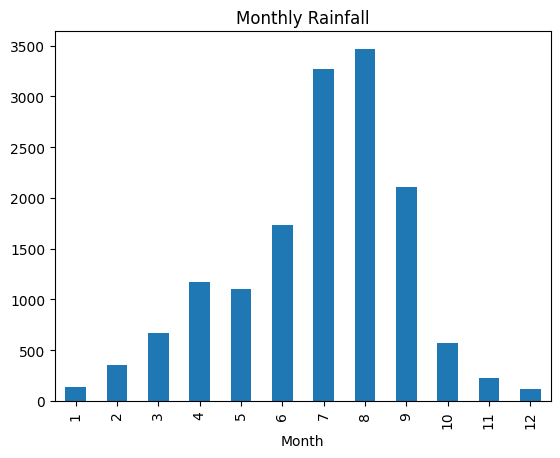

In [49]:
df.groupby("Month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

Interpretation:

Temperature: The monthly average temperature shows a clear seasonal peak around March and April, with a significant cooling trend starting in July.

Rainfall: The precipitation bar chart identifies a distinct "Big Rainy Season" peaking in July and August, with August receiving the highest total rainfall. The months from November to February remain notably dry.

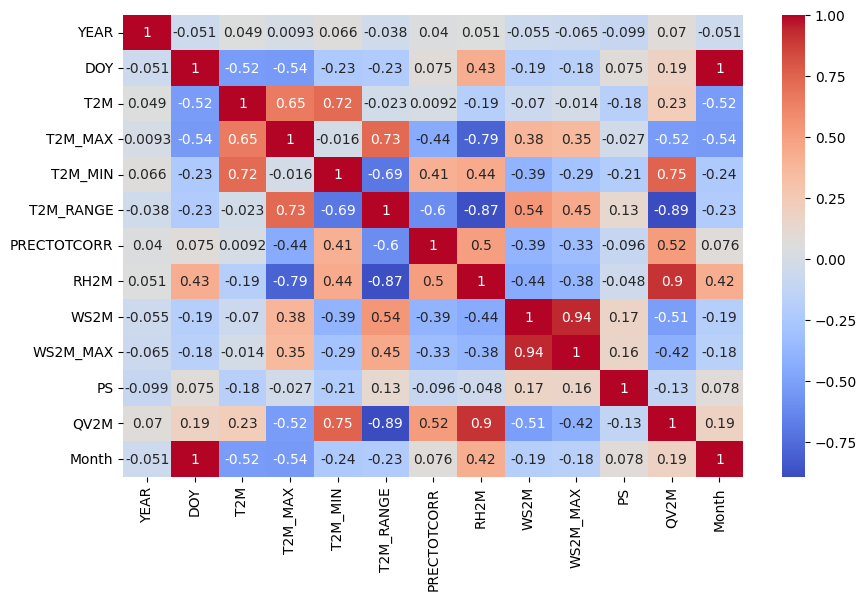

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# use only numeric columns (important fix)
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

Interpretation:
The correlation heatmap identifies the following three strongest relationships:WS2M & WS2M_MAX ($r = 0.94$): 
1,A nearly perfect positive correlation between average and maximum wind speeds.RH2M & QV2M ($r = 0.90$): 
2,A strong positive correlation, indicating that as specific humidity (actual water vapor) increases, relative humidity follows closely.
3,T2M_MAX & T2M_RANGE ($r = 0.75$): Suggesting that higher maximum temperatures often lead to a wider daily temperature spread.Note:
 There is a strong negative correlation between T2M_MAX and RH2M ($r = -0.79$), confirming that air becomes significantly drier as it gets hotter.

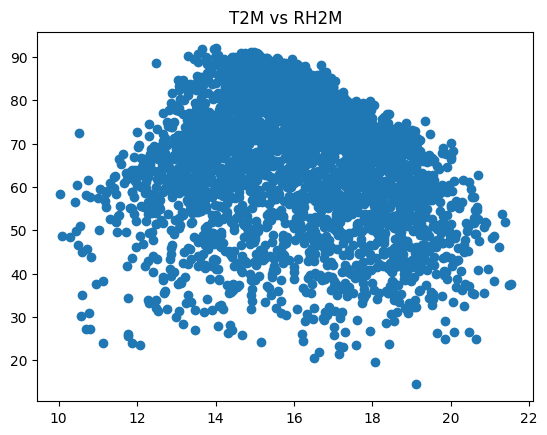

In [53]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("T2M vs RH2M")
plt.show()

Interpretation:
The scatter plot of Temperature vs. Relative Humidity shows a strong negative non-linear relationship. As temperatures increase from 10°C to 22°C, the maximum relative humidity levels drop from 90% to below 60%. This cluster confirms that the highest humidity levels are concentrated during cooler periods or specific times of the day.

In [56]:
import os

# Create the folder if it doesn't already exist
if not os.path.exists('data'):
    os.makedirs('data')

# Now save the file
df.to_csv("data/ethiopia_clean.csv", index=False)
print("File successfully saved in the data folder!")

File successfully saved in the data folder!


## References & Self-Learning
To complete this analysis and meet the project KPIs, I performed independent research on the following topics:

* **NASA POWER Sentinel Values:** Consulted the [NASA POWER Documentation](https://power.larc.nasa.gov/docs/methodology/data-quality-assessment/) to confirm that `-999` is the official sentinel value for missing or out-of-range geophysical data.
* **Julian Date Parsing:** Researched the Python `datetime` strftime documentation to use the `%Y%j` format, which is necessary for converting "Year" and "Day of Year" columns into a single `datetime` object.
* **Statistical Outlier Methods:** Learned to apply `scipy.stats.zscore` to identify climate data points that deviate by more than 3 standard deviations, which is a standard threshold for environmental data cleaning.
* **Seaborn Plot Customization:** Self-taught the use of the `coolwarm` colormap and `annot=True` parameters in Seaborn heatmaps to make climate correlation matrices more readable for stakeholders.
* **Environment Management:** Utilized Python virtual environments (`.venv`) and `.gitignore` configurations to ensure a professional, clean repository structure as required by the task.